
# **Climate Change Analysis**

In this project, I investigated data on climate change, or the long-term shifts in temperatures and weather patterns!



---

Importing the `datascience`, `numpy`, and `matplotlib` libraries.

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
np.set_printoptions(legacy='1.13')

import warnings
warnings.simplefilter('ignore')

import plotly.graph_objects as go

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Temperatures

In the following analysis, I investigated one of the 21st century's most prominent issues: climate change. I learned about climate change just by analyzing public records of different cities' temperature and precipitation over time.

I analyzed a collection of historical daily temperature and precipitation measurements from weather stations in 210 U.S. cities. The dataset was compiled by Yuchuan Lai and David Dzombak [1]; a description of the data from the original authors and the data itself is available [here](https://kilthub.cmu.edu/articles/dataset/Compiled_daily_temperature_and_precipitation_data_for_the_U_S_cities/7890488). 

### Cities

Reading the `cities` dataset

In [2]:
cities = Table.read_table('city_info.csv', index_col=0)
cities.show(3)

Name,ID,Lat,Lon,Stn.Name,Stn.stDate,Stn.edDate
Lander,USW00024021,42.8153,-108.726,LANDER WBO,1892-01-01,1946-05-28
Lander,USW00024021,42.8153,-108.726,LANDER HUNT FIELD,1946-05-29,2021-12-31
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE WBO,1871-01-01,1935-08-31


The `cities` table has one row per weather station and the following columns:

1. `"Name"`: The name of the US city
2. `"ID"`: The unique identifier for the US city
3. `"Lat"`: The latitude of the US city (measured in degrees of latitude)
4. `"Lon"`: The longitude of the US city (measured in degrees of longitude)
4. `"Stn.Name"`: The name of the weather station in which the data was collected
5. `"Stn.stDate"`: A string representing the date of the first recording at that particular station
6. `"Stn.edDate"`: A string representing the date of the last recording at that particular station

The data lists the weather stations at which temperature and precipitation data were collected. Note that although some cities have multiple weather stations, only one is collecting data for that city at any given point in time. Thus, I just focussed on the cities themselves.


---

Creating a scatter plot that plots the latitude and longitude of every city in the `cities` table so that the result places northern cities at the top and western cities at the left.


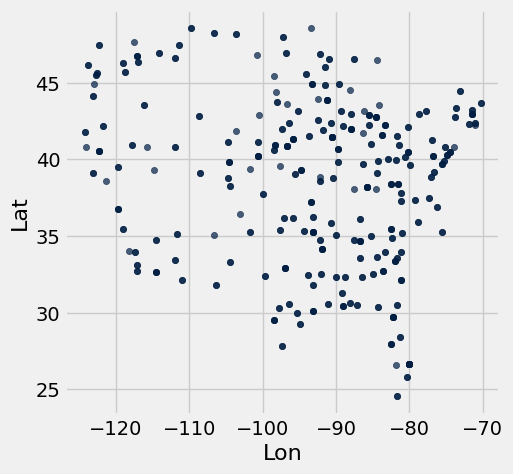

In [3]:
cities.scatter("Lon", "Lat")

<!-- END QUESTION -->

These cities are all within the continental U.S., and so the general shape of the U.S. is visible in the plot. The shape will appear distorted compared to most maps for two reasons: the scatter plot is square even though the U.S. is wider than it is tall, and this scatter plot is an [equirectangular projection](https://en.wikipedia.org/wiki/Equirectangular_projection) of the spherical Earth. A geographical map of the same data uses the common [Pseudo-Mercator projection](https://en.wikipedia.org/wiki/Web_Mercator_projection).

In [4]:
fig = go.Figure(data=go.Scattergeo(
        lon = cities.column('Lon'),
        lat = cities.column('Lat'),
        text = cities.column('Name'),
        mode = 'markers'))

fig.update_layout(geo_scope='usa', width=800, height=500, margin={'r': 0, 't': 0, 'l': 0, 'b': 0})
fig.show()

The points seems to be cluster around known populated areas and states. Thus, the cities are geographically concentrated according to human settlement patterns and not sampled uniformly at random across U.S.

---

Assigned `num_unique_cities` to the number of unique cities that appear in the `cities` table.

In [5]:
num_unique_cities = len(cities.group("Name").column("Name"))

print(f"There are {num_unique_cities} unique cities that appear within our dataset.")

There are 210 unique cities that appear within our dataset.


In order to investigate further, it will be helpful to determine what region of the United States each city was located in: Northeast, Northwest, Southeast, or Southwest. I used the following geographical boundaries:

<img src= "usa_coordinates.png" alt="USA Coordinate Map" width="600"/>

1. A station is located in the `"Northeast"` region if its latitude is above or equal to 40 degrees and its longitude is greater than or equal to -100 degrees.
2. A station is located in the `"Northwest"` region if its latitude is above or equal to 40 degrees and its longitude is less than -100 degrees.
3. A station is located in the `"Southeast"` region if its latitude is below 40 degrees and its longitude is greater than or equal to -100 degrees.
4. A station is located in the `"Southwest"` region if its latitude is below 40 degrees and its longitude is less than -100 degrees.

---

I created `coordinates_to_region` function that takes in two arguments, a city's latitude (`lat`) and longitude (`lon`) coordinates, and output a string representing the region it is located in.


In [6]:
def coordinates_to_region(lat, lon):
    if lat >= 40:
        if lon >= -100:
            return "Northeast"
        elif lon < -100:
            return "Northwest"

    elif lat < 40:
        if lon >= -100:
            return "Southeast"
        else:
            return "Southwest"

---
Adding a new column in `cities` labeled `Region` that contains the region in which the city is located.

In [7]:
regions_array = cities.apply(coordinates_to_region, "Lat", "Lon")
cities = cities.with_columns("Region", regions_array)
cities.show(5)

Name,ID,Lat,Lon,Stn.Name,Stn.stDate,Stn.edDate,Region
Lander,USW00024021,42.8153,-108.726,LANDER WBO,1892-01-01,1946-05-28,Northwest
Lander,USW00024021,42.8153,-108.726,LANDER HUNT FIELD,1946-05-29,2021-12-31,Northwest
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE WBO,1871-01-01,1935-08-31,Northwest
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE MUNICIPAL ARPT,1935-09-01,2021-12-31,Northwest
Wausau,USW00014897,44.9258,-89.6256,Wausau Record Herald,1896-01-01,1941-12-31,Northeast


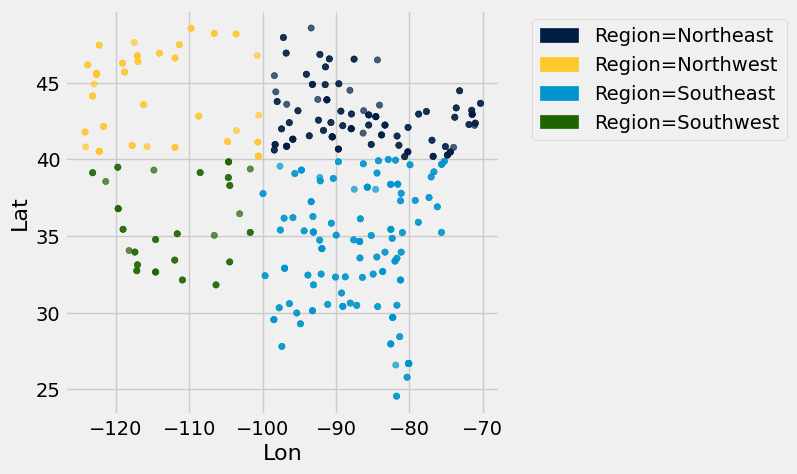

In [8]:
cities.scatter("Lon", "Lat", group="Region")

---

Creating a new table called `cities_nearest` that contains the same columns as the `cities` table and an additional column called `"Nearest"` that contains the **name of the nearest city** that is in a different region from the city described by the row.

In [9]:
cities.show(3)

Name,ID,Lat,Lon,Stn.Name,Stn.stDate,Stn.edDate,Region
Lander,USW00024021,42.8153,-108.726,LANDER WBO,1892-01-01,1946-05-28,Northwest
Lander,USW00024021,42.8153,-108.726,LANDER HUNT FIELD,1946-05-29,2021-12-31,Northwest
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE WBO,1871-01-01,1935-08-31,Northwest


In [10]:
def distance(lat0, lon0, lat1, lon1):
    "Approximate the distance between point (lat0, lon0) and (lat1, lon1) pairs in the arrays."
    return np.sqrt((lat0 - lat1) * (lat0 - lat1) + (lon0 - lon1) * (lon0 - lon1))

# Redefine find_nearest_city to take cities_df as a default argument
def find_nearest_city(row):
    # Extract current city's coordinates and region
    current_lat = row.item("Lat")
    current_lon = row.item("Lon")
    current_region = row.item("Region")
    
    # Filter cities in different regions (exclude current city's region)
    other_cities = cities.where(cities["Region"] != current_region)
    
    # Calculate distances to all other cities in different regions
    distances = distance(current_lat, current_lon, 
                        other_cities["Lat"], other_cities["Lon"])
    
    # Find the index of the nearest city (smallest distance)
    nearest_idx = np.argmin(distances)
    
    # Return the name of the nearest city
    return other_cities["Name"][nearest_idx]

# Apply the function to each row
nearest_cities = cities.apply(find_nearest_city)

# Add the "Nearest" column
cities_nearest = cities.with_columns("Nearest", nearest_cities)

# Show results
cities_nearest.show(5)

Name,ID,Lat,Lon,Stn.Name,Stn.stDate,Stn.edDate,Region,Nearest
Lander,USW00024021,42.8153,-108.726,LANDER WBO,1892-01-01,1946-05-28,Northwest,GrandJunction
Lander,USW00024021,42.8153,-108.726,LANDER HUNT FIELD,1946-05-29,2021-12-31,Northwest,GrandJunction
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE WBO,1871-01-01,1935-08-31,Northwest,Denver
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE MUNICIPAL ARPT,1935-09-01,2021-12-31,Northwest,Denver
Wausau,USW00014897,44.9258,-89.6256,Wausau Record Herald,1896-01-01,1941-12-31,Northeast,Springfield


In [11]:
near = cities_nearest.group(["Name", "Nearest"]).select("Name", "Nearest")
single = cities_nearest.take(np.arange(0, len(cities_nearest.column("Name")), 2))
near= near.join("Name", single, "Name").select("Name", "Nearest", "Region").relabel("Region", "Region_Name")
near= near.join("Nearest", single, "Name").select("Name", "Nearest", "Region_Name", "Region").relabel("Region", "Region_Near")
near

Name,Nearest,Region_Name,Region_Near
Williston,Aberdeen,Northwest,Northeast
ElPaso,Abilene,Southwest,Southeast
Roswell,Abilene,Southwest,Southeast
ColumbusOH,Akron,Southeast,Northeast
Zaneville,Akron,Southeast,Northeast
Abilene,Amarillo,Southeast,Southwest
Austin,Amarillo,Southeast,Southwest
CollegeStation,Amarillo,Southeast,Southwest
CorpusChristi,Amarillo,Southeast,Southwest
DallasFortWorth,Amarillo,Southeast,Southwest


### Phoenix, Arizona

Each city has a different CSV file full of daily temperature and precipitation measurements. The files for other cities can be downloaded [here](https://kilthub.cmu.edu/articles/dataset/Compiled_daily_temperature_and_precipitation_data_for_the_U_S_cities/7890488) by matching them to the ID of the city in the `cities` table.

Since Phoenix is located on the upper edge of the Sonoran Desert, it has some impressive temperatures.

The `phoenix` table has one row per day and the following columns:

1. `"Date"`: The date (a string) representing the date of the recording in **YYYY-MM-DD** format
2. `"tmax"`: The maximum temperature for the  day (°F)
3. `"tmin"`: The minimum temperature for the day (°F)
4. `"prcp"`: The recorded precipitation for the day (inches)

In [12]:
phoenix = Table.read_table("phoenix.csv", index_col=0)
phoenix.show(3)

Date,tmax,tmin,prcp
1896-01-01,66,30,0
1896-01-02,64,30,0
1896-01-03,68,30,0


---

Finding the date of the **largest temperature range** in Phoenix, Arizona for any day between January 1st, 2010 and December 31st, 2010. I used the variable `phoenix_with_ranges_2010` to filter the phoenix table to days in 2010 with an additional column corresponding to the temperature range for that day. 

In [18]:
phoenix_2010 = phoenix.where("Date", are.containing("2010"))
phoenix_with_ranges= phoenix_2010.with_columns("range", phoenix_2010.column("tmax") - phoenix_2010.column("tmin"))
largest_2010_range_date = phoenix_with_ranges.where("range", max(phoenix_with_ranges.column("range"))).column("Date").take(0)
largest_2010_range_date

'2010-06-24'

Checking the `phoenix` table to check the temperature readings for our `largest_2010_range_date` to see if anything special is going on.

In [14]:
phoenix.where("Date", largest_2010_range_date)

Date,tmax,tmin,prcp
2010-06-24,113,79,0


The maximum temperature the day is 113 degrees Fahrenheit which is very hot.

I created the function `extract_year_from_date` takes a date string in the **YYYY-MM-DD** format and returns an integer representing the **year**. I also created the function `extract_month_from_date` takes a date string and returns a string describing the month.

In [15]:
import calendar

def extract_year_from_date(date):
    """Returns an integer corresponding to the year of the input string's date."""
    return int(date[:4])

def extract_month_from_date(date):
    "Return an abbreviation of the name of the month for a string's date."
    month = date[5:7]
    return f'{month} ({calendar.month_abbr[int(date[5:7])]})'

print('2022-04-01 has year', extract_year_from_date('2022-04-01'),
      'and month', extract_month_from_date('2022-04-01'))

2022-04-01 has year 2022 and month 04 (Apr)


---

Adding two new columns `"Year"` and `"Month"` to the `phoenix` table that contain the year as an **integer** and the month as a **string** (such as `"04 (Apr)"`) for each day, respectively. 

In [19]:
years_array = phoenix.apply(extract_year_from_date, "Date")
months_array = phoenix.apply(extract_month_from_date, "Date")
phoenix = phoenix.with_columns("Year", years_array,
                               "Month", months_array)
phoenix.show(5)

Date,tmax,tmin,prcp,Year,Month
1896-01-01,66,30,0,1896,01 (Jan)
1896-01-02,64,30,0,1896,01 (Jan)
1896-01-03,68,30,0,1896,01 (Jan)
1896-01-04,69,34,0,1896,01 (Jan)
1896-01-05,70,46,0,1896,01 (Jan)



---

Creating an overlaid line plot of the **average maximum temperature** and **average minimum temperature** for each year between 1900 and 2020. 


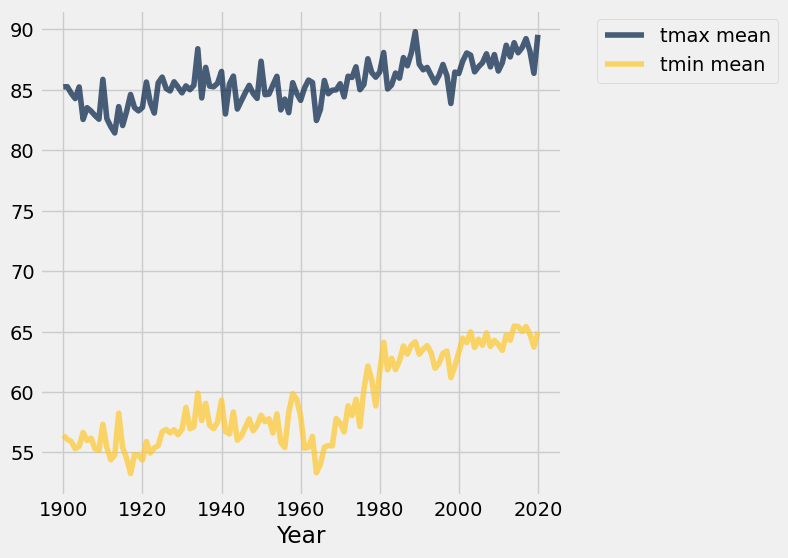

In [ ]:
tbl = phoenix.group("Year", np.mean).where("Year", are.contained_in(np.arange(1900, 2021)))
tbl = tbl.select("Year", "tmax mean", "tmin mean")
tbl.plot("Year")

---

Although still hotly debated, many climate scientists agree that the effects of climate change began to surface in the early 1960s as a result of elevated levels of greenhouse gas emissions.

However, looking at the line graph, the support for the claim can seen clearly through the upward trend in the average minimum temperatures starting at about 1960s. From roughly 1900 through the early 1960s, the average yearly maximum and minimum temperatures remain fairly stable with some fluctuations but no strong upward or downward trend. Beginning in the 1960s, I can see a noticeable rise in the average minimum and maximum temperature lines that continues steadily upward toward 2020. The range between the minimum temperature and maximum temperature also seems to decrease, meaning the global is increasing.

Averaging temperatures across an entire year can obscure some effects of climate change. For example, if summers get hotter but winters get colder, the annual average may not change much. 

Investigating how average **monthly** maximum temperatures have changed over time in Phoenix. 

---

Creating a `monthly_increases` table with one row per month and the following four columns in order: 
1. `"Month"`: The month (such as `"02 (Feb)"`)
2. `"Past"`: The average max temperature in that month from 1900-1960 (both ends inclusive)
3. `"Present"`: The average max temperature in that month from 2019-2021 (both ends inclusive)
4. `"Increase"`: The difference between the present and past average max temperatures in that month

In [20]:
def period(year):
    "Output if a year is in the Past, Present, or Other."
    if 1900 <= year <= 1960:
        return "Past"
    elif 2019 <= year <= 2021:
        return "Present"
    else:
        return "Other"

ph = phoenix.with_columns("Period", phoenix.apply(period, "Year"))
group = ph.group(["Month", "Period"], np.mean).where("Period", are.contained_in(["Past", "Present"]))
present = group.take(np.arange(1, len(group.column("Period")), 2)).column("tmax mean")
past = group.take(np.arange(0, len(group.column("Period")), 2)).column("tmax mean")
monthly_increases = Table().with_columns("Month", group.take(np.arange(1, len(group.column("Period")), 2)).column("Month"),
                                         "Past", past,
                                         "Present", present,
                                         "Increase", present-past)
monthly_increases.show()

Month,Past,Present,Increase
01 (Jan),65.0164,67.8312,2.81479
02 (Feb),68.8485,69.1859,0.337362
03 (Mar),74.6499,75.9796,1.32965
04 (Apr),82.6421,88.4,5.75792
05 (May),91.4299,94.571,3.14104
06 (Jun),101.166,105.734,4.56832
07 (Jul),103.599,107.245,3.64654
08 (Aug),101.416,107.384,5.96769
09 (Sep),97.6874,101.238,3.55035
10 (Oct),86.798,90.1667,3.36868


### February in Phoenix

The `"Past"` column values are averaged over many decades, and so they are reliable estimates of the average high temperatures in those months before the effects of modern climate change. However, the `"Present"` column is based on only three years of observations. February, the shortest month, has the fewest total observations: only 85 days.

In [21]:
feb_present = phoenix.where('Year', are.between_or_equal_to(2019, 2021)).where('Month', '02 (Feb)')
feb_present.num_rows

85

Compared to the other months, the increase for the month of February is quite small. The February difference is very close to zero. 

In [22]:
print(f"February Difference: {monthly_increases.row(1).item('Increase')}")

February Difference: 0.3373623297258632


Perhaps that small difference is somehow due to chance! To investigate this idea requires a thought experiment.

Observing all of the February maximum temperatures from 2019 to 2021 (the present period); there's no random sampling involved. But, we can imagine that if more years pass with the same present-day climate, there would be different but similar maximum temperatures in future February days. From the data I observe, I tried to estimate the **average maximum February temperature** in this imaginary collection of all future February days that would occur in our modern climate, assuming the climate doesn't change any further and many years pass.

I can also imagine that the maximum temperature each day is like a **random draw from a distribution of max daily temperatures for that month**. Treating actual observations of natural events as if they were each *randomly* sampled from some unknown distribution is a simplifying assumption. These temperatures were not actually sampled at random—instead they occurred due to the complex interactions of the Earth's climate, but treating them as if they were random abstracts away the details of this naturally occuring process and allows me to carry out statistical inference.  Conclusions are only as valid as the assumptions upon which they rest, but in this case thinking of daily temperatures as random samples from some unknown climate distribution seems at least plausible.

If I assume that the **actual temperatures were drawn at random from some large population of possible February days** in our modern climate, then I can not only estimate the population average of this distribution, but also quantify our uncertainty about that estimate using a confidence interval.

**I computed the confidence interval of the present February average max daily temperature.** To unpack this statement, this confidence interval is looking at present-day February conditions, and the confidence interval is for present-day February average max daily temperatures. I compared this confidence interval to the historical average (ie. the `"Past"` value in our `monthly_increases` table). Since I am essentially interested in seeing if the average February max daily temperatures have ***changed*** since the past, I care about whether the historical average lies within the confidence interval I create. 

- Null Hypothesis: The observed difference in average February maximum temperatures is due to random variation and the historical average lies within the confidence interval of the present period mean.

- Alternative Hypothesis: The historical average does not lie within the confidence interval of the present period mean, indicating a statistically significant difference in February temperatures.


---

Creating the function `make_ci`, which takes a one-column table `tbl` containing sample observations and a confidence `level` percentage such as 95 or 99. **It returns an array containing the lower and upper bound in that order, of a confidence interval** for the population mean constructed using 5,000 bootstrap resamples.

In [23]:
def make_ci(tbl, level):
    """Compute a level% confidence interval of the average of the population for 
    which column 0 of Table tbl contains a sample. This function should return an 
    array of the lower and upper bounds of the confidence interval.
    """
    stats = make_array()
    for k in np.arange(5000):
        stat = np.mean(tbl.sample().column(0))
        stats = np.append(stats, stat)
    lower_bound = percentile((100- level)/2, stats)
    upper_bound = percentile(100- (100- level)/2, stats)
    return make_array(lower_bound, upper_bound)

feb_present_ci = make_ci(feb_present.select('tmax'), 99)
feb_present_ci

array([ 66.97176471,  71.30352941])


---

The `feb_present_ci` 99% confidence interval contains the observed past February average maximum temperature of 68.8485 from the `monthly_increases` table.

Since this historical average lies within the 99% confidence interval, at a 1% p-value cutoff, we fail to reject the null hypothesis that the February max temperatures have not changed. There is insufficient evidence at the 1% significance level to conclude that the average maximum temperature in February in Phoenix has changed significantly due to climate change between the two periods.

<!-- END QUESTION -->

### All Months

---

Repeating the process of seeing whether the **past average for each month** is **contained within the 99% confidence interval** of the **present average**.

In [24]:
comparisons = make_array()
months = monthly_increases.column(0)
for month in months:
    past_average = monthly_increases.where("Month", month).column("Past").item(0)
    present_observations = ph.where("Month", month).where("Period", "Present").select("tmax")
    present_ci = make_ci(present_observations, 99)
    
    GREEN_BOLD = '\033[1;32m'
    RED_BOLD = '\033[1;31m'
    RESET_STYLE = '\033[0m'
    within = (past_average >= present_ci.item(0)) and (past_average <= present_ci.item(1))
    if within:
        comparison = f'{GREEN_BOLD}contained{RESET_STYLE}'
    else:
        comparison = f'{RED_BOLD}NOT contained{RESET_STYLE}'
    comparisons = np.append(comparisons, comparison)
    
    print(f'For {month} the past avg {round(past_average, 1)} is {comparison} in the interval '
           f'{np.round(present_ci, 1)}, the 99% CI of the present avg.\n')

For 01 (Jan) the past avg 65.0 is NOT contained in the interval [ 66.3  69.3], the 99% CI of the present avg.

For 02 (Feb) the past avg 68.8 is contained in the interval [ 67.1  71.3], the 99% CI of the present avg.

For 03 (Mar) the past avg 74.6 is contained in the interval [ 74.  78.], the 99% CI of the present avg.

For 04 (Apr) the past avg 82.6 is NOT contained in the interval [ 86.4  90.4], the 99% CI of the present avg.

For 05 (May) the past avg 91.4 is NOT contained in the interval [ 92.5  96.6], the 99% CI of the present avg.

For 06 (Jun) the past avg 101.2 is NOT contained in the interval [ 104.2  107.2], the 99% CI of the present avg.

For 07 (Jul) the past avg 103.6 is NOT contained in the interval [ 105.5  108.7], the 99% CI of the present avg.

For 08 (Aug) the past avg 101.4 is NOT contained in the interval [ 105.7  108.9], the 99% CI of the present avg.

For 09 (Sep) the past avg 97.7 is NOT contained in the interval [  99.2  103.1], the 99% CI of the present avg.




---



I noticed that significant warming was detected in 9/12 months. I rejected Null Hypothesis for January and April to November, indicating statistically significant increases in average maximum temperatures. Largest increases occurred in summer months from June to August, where present temperatures are 3–6 degrees F higher than historical averages. However, I failed to reject Null Hypothesis for February, March, and December, suggesting these months have not warmed significantly at the 1% significance level. February’s small increase of 0.34 degrees F aligns with its smaller sample size of 85 days. There is a seasonal pattern because in Winter from Dec to Feb, only January showed significant warming. For, Spring from Mar to May and Summer from Jun to Aug showed the strongest evidence of warming where all months are significant. Lastly, for Fall from Sep to Nov, there is consistent warming.

<!-- END QUESTION -->

> It is important to be wary of making conclusions based on the results of multiple hypothesis tests. Specifically, a 1% p-value cutoff means that if the null is true, we would expect to incorrectly reject the null 1% of the time. Now, if I run multiple of these tests, the chance of observing an error will be greater than if I had just run one test as the error chance compounds. 

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Drought

According to the [United States Environmental Protection Agency](https://www.epa.gov/climate-indicators/southwest), "Large portions of the Southwest have experienced drought conditions since weekly Drought Monitor records began in 2000. For extended periods from 2002 to 2005 and from 2012 to 2020, nearly the entire region was abnormally dry or even drier." 

Assessing the impact of drought is challenging with just city-level data because so much of the water that people use is transported from elsewhere, but I explored the data I have and see what I can learn.

First, let's take a look at the precipitation data in the Southwest region. The `southwest.csv` file contains total annual precipitation for 13 cities in the southwestern United States for each year from 1960 to 2021. This dataset is aggregated from the daily data and includes only the Southwest cities from the original dataset that have consistent precipitation records back to 1960.

In [25]:
southwest = Table.read_table('southwest.csv')
southwest.show(5)

City,Year,Total Precipitation
Albuquerque,1960,8.12
Albuquerque,1961,8.87
Albuquerque,1962,5.39
Albuquerque,1963,7.47
Albuquerque,1964,7.44


---

Creating a table `totals` that has one row for each year in chronological order. It contains the following columns:
1. `"Year"`: The year
2. `"Precipitation"`: The total precipitation in all 13 southwestern cities that year


In [26]:
totals = southwest.drop("City").group("Year", np.sum).sort("Year").relabel("Total Precipitation sum", "Precipitation")
totals

Year,Precipitation
1960,149.58
1961,134.82
1962,130.41
1963,132.18
1964,123.41
1965,187.53
1966,120.27
1967,179.02
1968,136.25
1969,191.72


Plotting the total precipitation in these cities over time, so that I can try to spot the drought visually. The drought years given by the EPA were  (2002-2005) and (2012-2020).

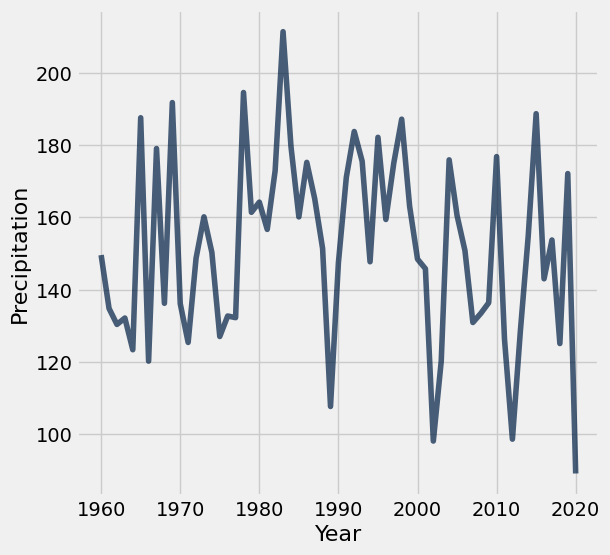

In [27]:
totals.plot("Year", "Precipitation")

This plot is not very revealing. Each year has a different amount of precipitation, and there is quite a bit of variability across years, as if each year's precipitation is a random draw from a distribution of possible outcomes. 

Could it be that these so-called "drought conditions" from 2002-2005 and 2012-2020 can be explained by chance? In other words, could it be that the annual precipitation amounts in the Southwest for these drought years are like **random draws from the same underlying distribution** as for other years? Perhaps nothing about the Earth's precipitation patterns has really changed, and the Southwest U.S. just happened to experience a few dry years close together. 

To assess this idea, I conducted an A/B test in which **each year's total precipitation** is an outcome, and the condition is **whether or not the year is in the EPA's drought period**.

This `drought_label` function distinguishes between drought years as described in the U.S. EPA statement above (2002-2005 and 2012-2020) and other years. I know that the label "other" is perhaps misleading, since there were other droughts before 2000, such as the massive [1988 drought](https://en.wikipedia.org/wiki/1988%E2%80%9390_North_American_drought) that affected much of the U.S. However, I am interested in whether these modern drought periods (2002-2005 and 2012-2020) are *normal* or *abnormal*, it makes sense to distinguish the years in this way. 

In [28]:
def drought_label(n):
    """Return the label for an input year n."""
    if 2002 <= n <= 2005 or 2012 <= n <= 2020:
        return 'drought'
    else:
        return 'other'

- Null hypothesis: The average annual precipitation during drought years (2002–2005 and 2012–2020) is the same as the average for other years. Any observed difference is due to random chance.

- Alternative hypothesis: The average annual precipitation during drought years is less than the average for other years. Drought years are significantly drier than non-drought years.


---

Defining the table `drought`. It contains one row per year and the following two columns:
- `"Label"`: Denotes if a year is part of a `"drought"` year or an `"other"` year
- `"Precipitation"`: The sum of the total precipitation in 13 Southwest cities that year

Then, I constructed an overlaid histogram of two observed distributions: the total precipitation in drought years and the total precipitation in other years. 


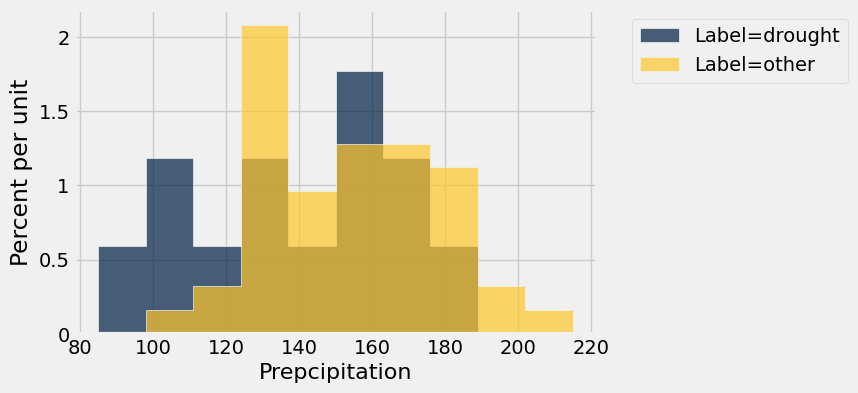

In [29]:
bins = np.arange(85, 215+1, 13)
drought = Table().with_columns("Label", totals.apply(drought_label, "Year"),
                               "Prepcipitation", totals.column("Precipitation"))
drought.hist("Prepcipitation", bins= bins, group= "Label");


---

If someone points out that there are more **other** years than **drought** years, and so measuring the difference between total precipitation will always favor the **other** years. They conclude that all of the options above involving **total** precipitation are invalid test statistic choices.

I agree with them because there are more "other" years than "drought" years in the dataset so simply measuring the difference between total precipitation for each group will almost always lead to a larger value for the group with more years, regardless of the precipitation in each. This imbalance in group size means that total precipitation differences does not fairly reflect the effect of drought status. They are confounded by frequency. A valid test statistic would be the average precipitation per year in each group. Averages allow for direct, fair comparison, as they are independent of how many years are in each group.

In [30]:
drought.show(3)

Label,Prepcipitation
other,149.58
other,134.82
other,130.41


In [31]:
drought.group('Label')

Label,count
drought,13
other,48


---

For the A/B test, I used the difference between the average precipitation in drought years and the average precipitation in other years as our test statistic:

$$\text{average precipitation in ``drought" years} - \text{average precipitation in ``other" years}$$

First, I created the function `test_statistic`. It takes in a two-column table `t` with one row per year and two columns:
- `"Label"`: the label for that year (either `"drought"` or `"other"`)
- `"Precipitation"`: the total precipitation in the 13 Southwest cities that year. 

Then, I used the function to assign `observed_statistic` to the observed test statistic.

In [32]:
def test_statistic(t):
    group = t.group("Label", np.mean)
    return group.column(1).item(0) - group.column(1).item(1) 

observed_statistic = test_statistic(drought)
observed_statistic

-15.856714743589748

Now that I have defined the hypotheses and test statistic, I conducted the hypothesis test. I started by defining a function to simulate the test statistic under the null hypothesis, and then called that function 5,000 times to construct an empirical distribution under the null hypothesis.

---

Created a function to simulate the test statistic under the null hypothesis. The `simulate_precipitation_null` function simulates the null hypothesis once and returns the value of the test statistic for that simulated sample.


In [43]:
def simulate_precipitation_null():
    simulated = drought.with_column("Label", drought.sample(with_replacement= False).column("Label"))
    stats = test_statistic(simulated)
    return stats

simulate_precipitation_null()

-4.321458333333339

The simulation computes 5,000 values of the test statistic under the null hypothesis and stores the result in the array `sampled_stats`.


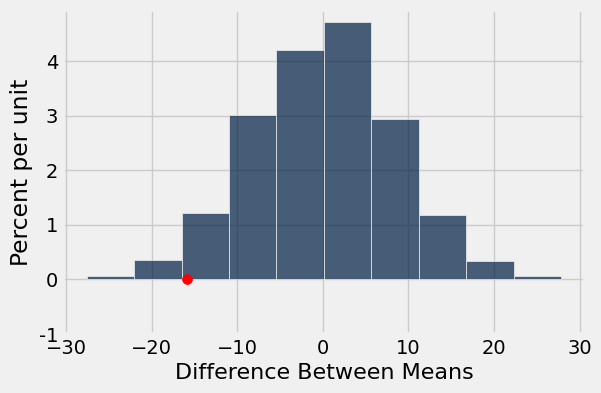

In [44]:
sampled_stats = make_array()

repetitions = 5000
for i in np.arange(repetitions):
    stat = simulate_precipitation_null()
    sampled_stats = np.append(sampled_stats, stat)

Table().with_column('Difference Between Means', sampled_stats).hist()
plt.scatter(observed_statistic, 0, c="r", s=50);
plt.ylim(-0.01);

---

Calculating the p-value for this hypothesis test.


In [50]:
precipitation_p_val = np.average(observed_statistic >= sampled_stats)
round(precipitation_p_val, 4)

0.026200000000000001

We reject the Null Hypothesis because the p-value of 0.0262 is less than the 5% significance level. There is statistically significant evidence that the average annual precipitation in drought years is lower than in other years. This supports the statement that the Southwest experienced unusually dry periods during the drought years and these conditions are unlikely to be explained by random fluctuations alone.

The conclusion may not fully apply to the entire Southwest region of the U.S. because the Southwest is geographically and climatically diverse. It includes dry deserts with minimal precipitation as well as higher elevation mountain areas that receive significantly more snowfall and rainfall. Variability in local topography, elevation, and weather patterns means that precipitation trends and drought impacts can differ substantially across the region. So, while the test shows drought years were drier on average in the sampled cities, this might not capture all geographic differences within the whole Southwest.


<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# Conclusion

Data science plays a central role in climate change research because massive simulations of the Earth's climate are necessary to assess the implications of climate data recorded from weather stations, satellites, and other sensors. [Berkeley Earth](http://berkeleyearth.org/data/) is a common source of data for analysis.

In this project, I applied my statistical inference technqiues that rely on random sampling even in situations where the data were not generated randomly, but instead by some complicated natural process that appeared random. I made assumptions about randomness and then came to conclusions based on those assumptions. Great care must be taken to choose assumptions that are realistic, so that the resulting conclusions are not misleading. However, making assumptions about data can be productive when doing so allows inference techniques to apply to novel situations.


---

## Author: 
- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)